## This is the code to train the model and acquire influence for Number of Samples Experiment

**Default Code**:   
The current default code is a runnable sample. It runs on the synthetic dataset generated with sklearn's make_classification function. The default version code provides the synthetic dataset with 16500 samples and 160 features in total. The separation is set to 5 to make sure the dataset is distinguishable by the model. All features are set to be informative to ensure they are of equal importance. The dataset has only two labels, so it is a binary classification problem. The default setting will then generate the training set and test set from the pool. The default training sample size is 8000, and the test size is 500. The number of features is set to 10. The model in default will be a Simple FeedForward Neural Network constructed by TensorFlow. The Influence Estimation methods we provide by default are the Influence Function and TracIn. If you simply press 'play', the default code will generate ranked influence lists for both Influence Function and TracIn with respect to the above mentioned setting in the root directory. The result lists could then be fed into other analyses.

**By default, this is exactly the same code as the base code. Please refer to the base code for more detailed explanation.**

**Guideline**:  
Read in / Construct Datasets -> **Choose the Training Sample Size** -> Pre-processing -> Model Training -> Influence Estimation -> Store the Ranked Influence lists -> **Change the Training Sample Size and Repeat all the process** -> ... -> **After all the training and estimation, feed the results into the analysis code**  (Remember to change the file name in the last block to save lists in different settings.)

# Import Area

Here is the area to place all the import codes. You don't need to change here unless you want to customise in later sections.

In [841]:
import tensorflow as tf
import keras
from keras.utils import to_categorical
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

In [842]:
from keras import Sequential
from keras.layers import Dense, BatchNormalization, Dropout
from keras.losses import CategoricalCrossentropy
from keras.optimizers import Adam

In [843]:
from deel.influenciae.common import InfluenceModel, ExactIHVP
from deel.influenciae.influence import FirstOrderInfluenceCalculator
from deel.influenciae.utils import ORDER
from deel.influenciae.trac_in import TracIn

In [844]:
import random
from keras.optimizers import SGD

In [845]:
from sklearn.datasets import make_classification

In [846]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# Dataset Construction Area

**You can use any dataset you wish here, either regression or classification. But in default, since we are using influenciae's IF and TC method, make sure they are split into train and test sets, and then stored as tensorflow dataset format. If you only want to change the dataset, you can only change the code in the first two blocks to read in/ generate your own dataset. But remember to have features X and target y before going to the third block. Also, if you wish to everything on your own, remember to add id inside the dataset.** Since our default code is for classification, the regression might need a lot of changes in all the following sections.


**Input**: Dataset chosen(Usually in Features X and Target y format)  
**Output**: Tensorflow format Train and Test Set  
**Guideline**: Input -> Turn into Dataframe and add ID -> Pre-Processing -> Change the format to Tensorflow -> Output

The default code now produces a synthetic dataset with 16500 pool, 160 features with binary classification problems. The later options will turn that into a 10 features, 8000 train set and 500 test set sample. Both sets will then be turned into TensorFlow format and will wait for training.

**The most important thing in this code is changing the train size. In this experiment, all the other things are fixed, but the number of training sample is changing to test on different number of samples.**

1. Set your default setting here. train_pool + test_size = Total Dataset Size. train_sizes determines the later subset data. Sep to make sure the dataset is distinguishable.

In [847]:
train_pool = 10000
test_size = 500
train_sizes=[1000,2000,3000,4000,5000,6000,7000,8000,9000,10000]
seed=42

2. Construct the Synthetic Dataset with Make Classification here. **Could replace this with other datasets with X and y.**

In [848]:
df = pd.read_csv("diamonds.csv")

       features/carat  features/clarity  features/color  features/cut  \
0                1.26                 2               4             2   
1                0.80                 3               4             4   
2                0.56                 4               2             4   
3                1.51                 3               6             1   
4                0.33                 6               5             4   
...               ...               ...             ...           ...   
53935            1.02                 2               4             2   
53936            0.93                 2               4             3   
53937            0.30                 4               5             4   
53938            0.36                 3               2             4   
53939            0.70                 1               2             2   

       features/depth  features/table  features/x  features/y  features/z  \
0           60.599998            60.0        6

In [849]:
median_price = df["price"].median()
df["label"] = (df["price"] > median_price).astype(int)
df = df.drop(columns=['price'])

In [850]:
features = [
    "features/carat",
    "features/clarity",
    "features/color",
    "features/cut",
    "features/depth",
    "features/table",
    "features/x",
    "features/y",
    "features/z",
]

X = df[features]

X = StandardScaler().fit_transform(X)

nbrs = NearestNeighbors(n_neighbors=10500)

nbrs.fit(X)

NearestNeighbors(n_neighbors=10500)

In [851]:
# for center in np.random.choice(len(df),100):

#     distances, indices = nbrs.kneighbors(
#         X[center].reshape(1,-1)
#     )

#     local = df.iloc[indices[0]]

#     ratio = local["label"].mean()

#     if 0.4 < ratio < 0.6:

#         print(center)
#         print(ratio)

#         break

In [852]:
center = 32264

distances, indices = nbrs.kneighbors(
    X[center].reshape(1, -1)
)

local_df = df.iloc[indices[0]].copy()
local_distances = distances[0]
local_indices = indices[0]

print("Local size:", len(local_df))
print("Label ratio:", local_df["label"].mean())

print("\nDistance summary:")
print(pd.Series(local_distances).describe())

Local size: 10500
Label ratio: 0.520095238095238

Distance summary:
count    10500.000000
mean         1.818185
std          0.334028
min          0.000000
25%          1.627980
50%          1.896888
75%          2.086287
max          2.231709
dtype: float64


In [853]:
random_indices = np.random.choice(len(df), size=10500, replace=False)
random_distances = np.linalg.norm(
    X[random_indices] - X[center],
    axis=1
)

print("\nRandom distance summary:")
print(pd.Series(random_distances).describe())


Random distance summary:
count    10500.000000
mean         3.101650
std          1.078652
min          0.148894
25%          2.369623
50%          2.972903
75%          3.665986
max         23.108859
dtype: float64


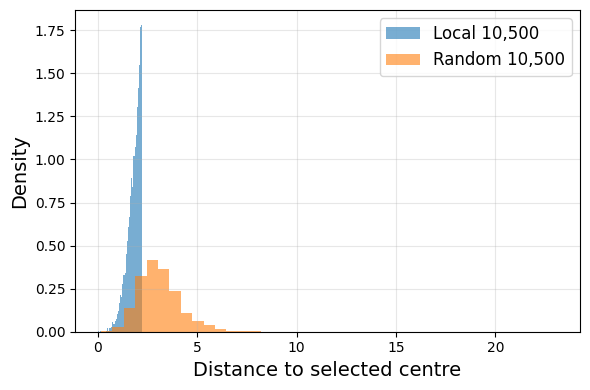

In [854]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.hist(local_distances, bins=40, alpha=0.6, density=True, label="Local 10,500")
plt.hist(random_distances, bins=40, alpha=0.6, density=True, label="Random 10,500")

plt.xlabel("Distance to selected centre", fontsize=14)
plt.ylabel("Density", fontsize=14)
plt.legend(fontsize=12)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [855]:
print("Mean distance")
print("Local :", np.mean(local_distances))
print("Random:", np.mean(random_distances))

print("Median distance")
print("Local :", np.median(local_distances))
print("Random:", np.median(random_distances))

print("Max distance")
print("Local :", np.max(local_distances))
print("Random:", np.max(random_distances))

Mean distance
Local : 1.818184738698328
Random: 3.101649596998204
Median distance
Local : 1.8968876503288916
Random: 2.9729033262106954
Max distance
Local : 2.2317087702930634
Random: 23.108859035142853


In [856]:
local_df = local_df.sample(frac=1, random_state=42)
chunks = np.array_split(local_df, 10)

D:\Python\pyfile\newnewinf\venv\new\lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [858]:
for i, chunk in enumerate(chunks):

    d = np.linalg.norm(
        X[chunk.index] - X[center],
        axis=1
    )

    print(
        i+1,
        d.mean(),
        d.std(),
        chunk["label"].mean()
    )

1 1.8093948346513444 0.34633427354842106 0.5238095238095238
2 1.8112271816166865 0.3305172427247881 0.49523809523809526
3 1.813174917644381 0.3381432255121973 0.54
4 1.801029195045253 0.3476267754251883 0.5190476190476191
5 1.8132068087711508 0.3343618902630504 0.5066666666666667
6 1.8287971323706402 0.3282929726505939 0.5171428571428571
7 1.8302800278694702 0.3209668335351515 0.5361904761904762
8 1.828076505547085 0.3249853261555477 0.5466666666666666
9 1.8215186981251121 0.34270135877807634 0.5085714285714286
10 1.8251420853421574 0.32361485293619763 0.5076190476190476


In [816]:
print(local_df)

       features/carat  features/clarity  features/color  features/cut  \
32264            0.70                 2               3             4   
50793            0.71                 2               3             4   
16617            0.71                 2               3             4   
35033            0.71                 2               3             4   
17105            0.75                 2               3             4   
...               ...               ...             ...           ...   
40128            0.53                 3               2             2   
28254            0.51                 5               3             4   
39758            0.56                 3               2             2   
29696            0.73                 5               3             4   
41846            1.21                 3               3             4   

       features/depth  features/table  features/x  features/y  features/z  \
32264       62.700001            57.0        5

In [817]:
local_df = local_df.reset_index(drop=True)

In [818]:
feature_cols = [c for c in local_df.columns if c != "label"]

rename_dict = {
    old: f"feature_{i+1}"
    for i, old in enumerate(feature_cols)
}

local_df = local_df.rename(columns=rename_dict)

print(local_df.head())

   feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0       0.70          2          3          4  62.700001       57.0   
1       0.71          2          3          4  62.900002       57.0   
2       0.71          2          3          4  62.500000       57.0   
3       0.71          2          3          4  62.500000       57.0   
4       0.75          2          3          4  62.200001       57.0   

   feature_7  feature_8  feature_9  label  
0       5.69       5.64       3.55      0  
1       5.67       5.62       3.55      0  
2       5.72       5.64       3.55      0  
3       5.67       5.69       3.55      1  
4       5.84       5.80       3.62      1  


In [819]:
df = local_df.copy()

3. Turn the X and y into dataframe for easy further processing. Add ID column to easy retrieve samples within IF/TC.

In [820]:
df['id'] = np.arange(1, len(df) + 1)
print(df)

       feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0           0.70          2          3          4  62.700001       57.0   
1           0.71          2          3          4  62.900002       57.0   
2           0.71          2          3          4  62.500000       57.0   
3           0.71          2          3          4  62.500000       57.0   
4           0.75          2          3          4  62.200001       57.0   
...          ...        ...        ...        ...        ...        ...   
10495       0.53          3          2          2  63.200001       58.0   
10496       0.51          5          3          4  61.599998       56.0   
10497       0.56          3          2          2  62.000000       56.0   
10498       0.73          5          3          4  61.000000       56.0   
10499       1.21          3          3          4  62.000000       56.0   

       feature_7  feature_8  feature_9  label     id  
0           5.69       5.64       3.55      

In [821]:
df = df.sample(
    frac=1,
    random_state=36
).reset_index(drop=True)

In [822]:
df_train_pool = df.iloc[:train_pool].reset_index(drop=True)
df_test = df.iloc[train_pool:].reset_index(drop=True)

In [823]:
print(df_train_pool.head())
print(df_test.head())

   feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0       0.52          4          1          4  61.799999       56.0   
1       1.11          1          4          4  62.700001       57.0   
2       1.04          3          3          4  61.799999       56.0   
3       1.08          2          2          3  61.299999       57.0   
4       0.61          1          1          4  62.000000       54.0   

   feature_7  feature_8  feature_9  label    id  
0       5.17       5.19       3.20      0  7350  
1       6.59       6.66       4.14      1  5269  
2       6.50       6.47       4.01      1  3421  
3       6.63       6.58       4.05      1  8998  
4       5.46       5.48       3.39      0  6344  
   feature_1  feature_2  feature_3  feature_4  feature_5  feature_6  \
0       0.53          5          3          4  61.400002       57.0   
1       0.74          1          3          2  63.799999       56.0   
2       1.11          1          2          3  62.099998    

4. Here, we choose the subset of the full dataset. By setting features_to_test, we have the subset feature size. By changing nested_train_dfs, we have different sample sizes.

In [824]:
nested_train_dfs = [df_train_pool.iloc[:size].reset_index(drop=True) for size in train_sizes]

**The most important thing in this experiment is the following code**:  
Based on the train_sizes=[1000,2000,3000,4000,5000,6000,7000,8000,9000,10000] defined above, we could map the number of training samples with the following code. By choosing the number in [], we could modify the train set size. Therefore, only changing the following code block is enough to produce the experiment result successfully.

In [825]:
train_df = nested_train_dfs[0]

In [826]:
X_train = train_df.drop(columns=["label"])
y_train = train_df["label"]
IDs = X_train["id"].values.reshape(-1, 1).astype(np.float32)
IDs = IDs  / 1e10

X_train = X_train.drop(columns=["id"]).values.astype(np.float32)
X_train = np.hstack((X_train, IDs))
y_train = to_categorical(y_train.values,num_classes=2)

print(X_train)

[[5.200e-01 4.000e+00 1.000e+00 ... 5.190e+00 3.200e+00 7.350e-07]
 [1.110e+00 1.000e+00 4.000e+00 ... 6.660e+00 4.140e+00 5.269e-07]
 [1.040e+00 3.000e+00 3.000e+00 ... 6.470e+00 4.010e+00 3.421e-07]
 ...
 [7.000e-01 3.000e+00 3.000e+00 ... 5.630e+00 3.510e+00 7.340e-08]
 [7.200e-01 3.000e+00 3.000e+00 ... 5.760e+00 3.600e+00 8.200e-09]
 [7.000e-01 2.000e+00 3.000e+00 ... 5.740e+00 3.510e+00 4.777e-07]]


In [827]:
test_df = df_test
X_test = test_df.drop(columns=["label"])
y_test = test_df["label"]
IDs = X_test["id"].values.reshape(-1, 1).astype(np.float32)
IDs = IDs  / 1e10

X_test = X_test.drop(columns=["id"]).values.astype(np.float32)
X_test = np.hstack((X_test, IDs))
y_test = to_categorical(y_test.values,num_classes=2)

print(X_test)

[[5.3000e-01 5.0000e+00 3.0000e+00 ... 5.2000e+00 3.1800e+00 1.0195e-06]
 [7.4000e-01 1.0000e+00 3.0000e+00 ... 5.7400e+00 3.6500e+00 8.0650e-07]
 [1.1100e+00 1.0000e+00 2.0000e+00 ... 6.5100e+00 4.1000e+00 8.6110e-07]
 ...
 [7.0000e-01 4.0000e+00 3.0000e+00 ... 5.7500e+00 3.5000e+00 2.9850e-07]
 [7.0000e-01 4.0000e+00 2.0000e+00 ... 5.7900e+00 3.4700e+00 9.1190e-07]
 [9.0000e-01 3.0000e+00 4.0000e+00 ... 6.1500e+00 3.8500e+00 6.1100e-08]]


5 (Optional) The following code below can display the samples distribution. Uncomment them to acquire the distribution plot.

In [828]:
# X_all = np.vstack([X_train, X_test])

# y_train_1d = np.argmax(y_train, axis=1)
# y_test_1d  = np.argmax(y_test, axis=1)
# y_all_1d = np.hstack([y_train_1d, y_test_1d])

In [829]:
# from sklearn.metrics import pairwise_distances
# from sklearn.manifold import MDS
# import seaborn as sns
# import matplotlib.pyplot as plt

In [830]:
# D = pairwise_distances(X_all) 

In [831]:
# X_mds = MDS(n_components=2, dissimilarity='precomputed', random_state=0).fit_transform(D)

In [832]:
# sns.scatterplot(x=X_mds[:,0], y=X_mds[:,1], hue=y_all_1d)
# plt.title("MDS – preserves original distances")

6. Now we have the train_ds and test_ds for training

In [833]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))

# Training Area

**Could modify the model as you wish here. Again, in default, influenciae relies on TensorFlow, so use the TensorFlow model if you only want to change the model. Remember: Store the InfluenceModel into the model_list with the loss function. The InfluenceModel will be used to obtain influence later. If you don't change the estimation methods, then the final output at this step shall always be the model_list**

**Input**:Train and Test Set from Data Construction Section   
**Output**: Model List  
**Guideline**: Input -> Define the Model and Hyperparameters -> Train the Model -> Output

Always remember to train the model, get the influence model and store that in model list, unless you wish to change the estimation methods.

The default code now use the train and test set generated from the last section to train the model. The default hyperparameters are: 300 Epochs, Simple FeedForward Neural Network, CategoricalCrossEntropy Loss function, SGD optimizer. Within each epoch, the current model will be turned into an Influence Model and stored inside a model list. After the training, the model list will be passed to next section for influence estimation.

In [834]:
from tensorflow.keras.regularizers import l2

1. **Could modify the model as you wish here as long as it is tensorflow.** Just remember: Store the InfluenceModel into the model_list with the loss function

In [835]:
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),  
    BatchNormalization(momentum=0.9),
    Dropout(0.0),
    Dense(8, activation='relu'),
    Dense(y_train.shape[1])
])
loss_fn = CategoricalCrossentropy(from_logits=True)
optimizer = SGD(learning_rate=0.001, momentum=0.9)
model.compile(loss=loss_fn, optimizer=optimizer, metrics=['accuracy'])

epochs = 300
unreduced_loss_fn = CategoricalCrossentropy(from_logits=True, reduction=tf.keras.losses.Reduction.NONE)
model_list = []
model_list.append(InfluenceModel(model, start_layer=-1, loss_function=unreduced_loss_fn))
for i in range(epochs):
  model.fit(train_ds.batch(256), epochs=1, validation_data=test_ds.batch(256), verbose=2)
  model_list.append(InfluenceModel(model, start_layer=-1, loss_function=unreduced_loss_fn))
base_loss, acc = model.evaluate(test_ds.batch(32), verbose=2)
print(base_loss)

4/4 - 1s - loss: 0.7310 - accuracy: 0.5220 - val_loss: 3.6431 - val_accuracy: 0.4680 - 509ms/epoch - 127ms/step
4/4 - 0s - loss: 0.6844 - accuracy: 0.5690 - val_loss: 2.5080 - val_accuracy: 0.4680 - 34ms/epoch - 9ms/step
4/4 - 0s - loss: 0.6766 - accuracy: 0.5760 - val_loss: 1.6041 - val_accuracy: 0.4680 - 36ms/epoch - 9ms/step
4/4 - 0s - loss: 0.6673 - accuracy: 0.5900 - val_loss: 1.0301 - val_accuracy: 0.4700 - 39ms/epoch - 10ms/step
4/4 - 0s - loss: 0.6579 - accuracy: 0.6060 - val_loss: 0.7759 - val_accuracy: 0.5120 - 54ms/epoch - 14ms/step
4/4 - 0s - loss: 0.6476 - accuracy: 0.6190 - val_loss: 0.6832 - val_accuracy: 0.5700 - 39ms/epoch - 10ms/step
4/4 - 0s - loss: 0.6381 - accuracy: 0.6470 - val_loss: 0.6590 - val_accuracy: 0.5980 - 42ms/epoch - 11ms/step
4/4 - 0s - loss: 0.6286 - accuracy: 0.6720 - val_loss: 0.6496 - val_accuracy: 0.6420 - 59ms/epoch - 15ms/step
4/4 - 0s - loss: 0.6198 - accuracy: 0.6900 - val_loss: 0.6286 - val_accuracy: 0.6760 - 42ms/epoch - 10ms/step
4/4 - 0s -

# Influence Estimation Area

**Again, you could use other influence analysis methods rather than IF/TC. You can also use any other Influence Function or TracIn implementation. Just Remember: 1. Make sure the package is unform throughout the framework. 2. Generate a Ranked influence list for each Influence Function and TracIn; Only the ranked influence list could be fed into the following analysis code.**

**The default code now use the model list, train set and test set to estimate the influence, and produce a ranked influence list for both IF and TC. The results are then saved in the root directory.**

**Input**:Model list from Training section, Train and Test Set from Data Construction Section   
**Output**: Two ranked Influence Lists for IF and TC.  
**Guideline**: Input -> Influence Estimation Methods -> Influence Matrix -> Output

1. Influence Function: Here we use the influenciae package. The following code will directly generate the influence list. If you wish to have the matrix, just use influence_matrix.

In [836]:
train_ids = []
test_ids = []
train_samples_np = np.array([x.numpy() for x, y in train_ds])
train_ids = [round(sample[-1] * 1e10) for sample in train_samples_np]

In [837]:
num_test_samples = len(test_ds)
num_train_samples = len(train_ids)
test_ids = []

influence_model = model_list[-1]
ihvp_calculator = ExactIHVP(influence_model, train_ds.batch(16))
influence_calculator = FirstOrderInfluenceCalculator(influence_model, train_ds, ihvp_calculator)

influence_matrix = np.zeros((num_test_samples, num_train_samples))

samples_to_explain = test_ds.take(num_test_samples).batch(1)
explanation_ds = influence_calculator.top_k(samples_to_explain, train_ds.batch(16), k=num_train_samples, order=ORDER.DESCENDING)
for test_idx,((sample, label), top_k_values, top_k_samples) in enumerate(explanation_ds.as_numpy_iterator()):
    test_sample_id = round(sample[0][-1] * 1e10)
    test_ids.append(test_sample_id)
    influential_ids = [round(s[-1] * 1e10) for s in top_k_samples[0]] 
    influence_scores = top_k_values[0]
    id_to_index = {train_id: idx for idx, train_id in enumerate(train_ids)}
    for inf_id, score in zip(influential_ids, influence_scores):
        if inf_id in id_to_index:
            influence_matrix[test_idx, id_to_index[inf_id]] = score

flattened_row = np.median(influence_matrix, axis=0).reshape(1, -1)
df = pd.DataFrame({'Train_ID': train_ids, 'Score': flattened_row.flatten()})
print(df)

     Train_ID     Score
0        7350  0.006239
1        5269  0.000790
2        3421  0.000630
3        8998  0.000578
4        6344  0.004021
..        ...       ...
995      4440  0.000419
996       866 -0.026868
997       734 -0.011206
998        82  0.029813
999      4777  0.020962

[1000 rows x 2 columns]


2. TracIn: Here we use the influenciae package. The following code will directly generate the influence list. If you wish to have the matrix, just use TracIn_matrix.

In [838]:
num_test_samples = len(test_ds)
num_train_samples = len(train_ids)
test_ids = []

TracIn_matrix = np.zeros((num_test_samples, num_train_samples))
influence_calculator = TracIn(
    model_list, 0.001
)
samples_to_explain = test_ds.take(num_test_samples).batch(1)
explanation_ds = influence_calculator.top_k(samples_to_explain, train_ds.batch(16), k=num_train_samples, order=ORDER.DESCENDING)
for test_idx,((sample, label), top_k_values, top_k_samples) in enumerate(explanation_ds.as_numpy_iterator()):
    test_sample_id = round(sample[0][-1] * 1e10)
    test_ids.append(test_sample_id)
    influential_ids = [round(s[-1] * 1e10) for s in top_k_samples[0]] 
    influence_scores = top_k_values[0]
    id_to_index = {train_id: idx for idx, train_id in enumerate(train_ids)}
    for inf_id, score in zip(influential_ids, influence_scores):
        if inf_id in id_to_index:
            TracIn_matrix[test_idx, id_to_index[inf_id]] = score

flattened_row = np.median(TracIn_matrix, axis=0).reshape(1, -1)
TracIn_df = pd.DataFrame({'Train_ID': train_ids, 'Score': flattened_row.flatten()})
print(TracIn_df)

     Train_ID     Score
0        7350 -0.000004
1        5269  0.000004
2        3421  0.000004
3        8998  0.000004
4        6344 -0.000041
..        ...       ...
995      4440  0.000003
996       866 -0.001152
997       734  0.000541
998        82  0.000325
999      4777 -0.000158

[1000 rows x 2 columns]


3. Here we turn both influence lists to the ranked influence lists and then store them for further processing.

In [839]:
df_sorted = df.sort_values(by="Score", ascending=False).reset_index(drop=True)

TracIn_sorted = TracIn_df.sort_values(by="Score", ascending=False).reset_index(drop=True)

In [840]:
TracIn_sorted.to_csv("TC_Train_Set_1_diamonds.csv",index = False)
df_sorted.to_csv("IF_Train_Set_1_diamonds.csv",index = False)